<a href="https://colab.research.google.com/github/FurkanOznamli/Machine_Learning/blob/CNN/CNN_Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Eğitim verisi şekli:", x_train.shape)
print("Test verisi şekli:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eğitim verisi şekli: (60000, 28, 28, 1)
Test verisi şekli: (10000, 28, 28, 1)


In [6]:
noise_factor = 0.2  # 0.2 - 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Gürültülü eğitim şekli:", x_train_noisy.shape)


Gürültülü eğitim şekli: (60000, 28, 28, 1)


In [7]:
from tensorflow.keras import layers, models

input_img = tf.keras.Input(shape=(28, 28, 1))

# ---- ENCODER ----
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

latent = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)

# ---- DECODER ----
x = layers.Conv2DTranspose(128, (3,3), strides=2, padding='same', activation='relu')(latent)
x = layers.Conv2DTranspose(64, (3,3), strides=2, padding='same', activation='relu')(x)

output_img = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, output_img)

autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=18,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)


Epoch 1/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.3621 - val_loss: 0.2778
Epoch 2/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.2735 - val_loss: 0.2700
Epoch 3/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.2672 - val_loss: 0.2669
Epoch 4/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2643 - val_loss: 0.2654
Epoch 5/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2631 - val_loss: 0.2646
Epoch 6/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2622 - val_loss: 0.2635
Epoch 7/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2607 - val_loss: 0.2629
Epoch 8/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2603 - val_loss: 0.2625
Epoch 9/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2605 - val_loss: 0.2622
Epoch 10/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2604 - val_loss: 0.2619
Epoch 11/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2588 - val_loss: 0.2615
Epoch 12/18
469/469 ━━━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


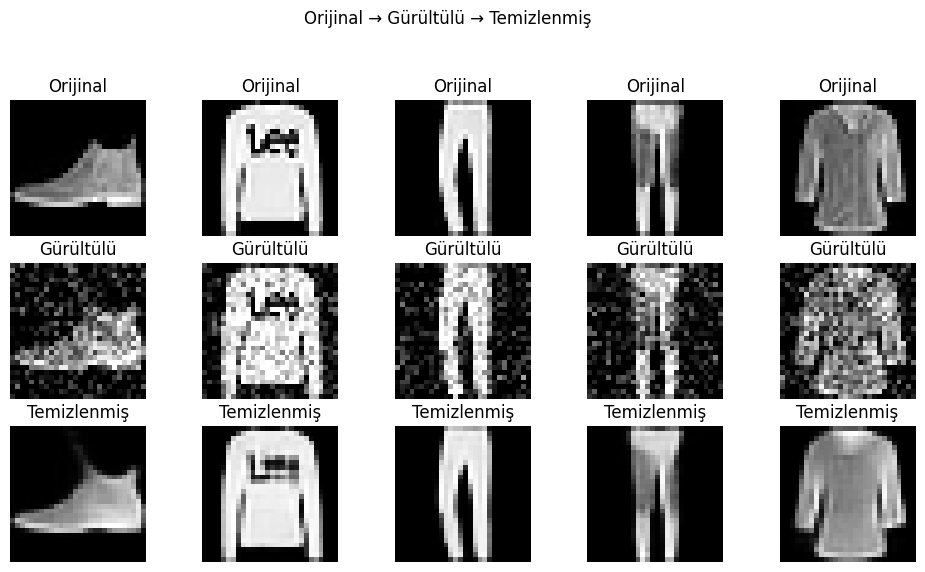

In [10]:
# Test verisinden 5 örnek seç
n = 5
plt.figure(figsize=(12, 6))

for i in range(n):

    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Orijinal")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Gürültülü")
    plt.axis("off")

    decoded_img = autoencoder.predict(x_test_noisy[i].reshape(1, 28, 28, 1))
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_img.reshape(28, 28), cmap="gray")
    plt.title("Temizlenmiş")
    plt.axis("off")

plt.suptitle("Orijinal → Gürültülü → Temizlenmiş", y=1.03)
plt.show()
